In [1]:
%matplotlib widget

In [2]:
# Compare 1D and 3D sorted

In [3]:
# Script to create synthetic 3D data

import numpy as np
import emg3d 
import empymod as ep
import pandas as pd
from scipy.constants import mu_0
import matplotlib.pyplot as plt
import time
from joblib import Parallel, delayed
import sys
sys.path.insert(1, 'src')

In [4]:
def FDEM1D_mdp(sgm, thk, height=0.15, ):
    """ 1D FDEM response 
        
    Parameters
    ----------
    sgm : array
           Array of electrical conductivities [S/m], len(sigma) = nlay

    thk : array
           Array of thicknesses [m], len(thk) = nlay - 1

    Freq : frequency of device [Hz]

    coilOrient : array of strings
                  coil orientations: 'H' for horizontal coplanar, 
                  'V' for vertical coplanar, 'P' for perpendicular

    coilSpacing : array
                    separations of the transmitter and receiver coils [m]

    height : float
                height of the device with respect to ground [m]
                
    norm : normalize values with respect to offset

    Returns
    -------
    Array [OP, IP]

    """  
    # Set geometry
    Freq = 9000
    coilSpacing = np.array([2, 4, 8])
    pcoilSpacing = np.array([2.1, 4.1,8.1])
    coilOrient = np.array(['H', 'V', 'P'])
    xsrc = np.array([-1, -2, -4])
    xrec = np.array([1, 2, 4])
    xsrc_p = np.array([-1.05, -2.05, -4.05])
    xrec_p = np.array([1.05, 2.05, 4.05])

    # Empty array to store responses
    HOP = []
    HIP = []
    VOP = []
    VIP = []
    POP = []
    PIP = []

    for x_src, x_rec, x_src_p, x_rec_p in zip(xsrc, xrec, xsrc_p, xrec_p):
        # Source and receivers geometry [x, y, z]
        
        source    = [x_src, 0, -height]
        receivers = [x_rec, 0, -height]    
        psource = [x_src_p, 0, -height]
        preceivers = [x_rec_p, 0, -height]

        # Depth and resistivity
        res_air = 1e6
        res = np.hstack((res_air, 1/sgm))
        depth = np.hstack((0, np.cumsum(thk)))

        if any(coilOrient == 'H'):
    
            H_Hs = ep.dipole(source, receivers, depth, res, Freq, ab = 66, xdirect=None, 
                              verb=0)*(2j * np.pi * Freq * mu_0) 
            H_Hp = ep.dipole(source, receivers, depth=[], res=[res_air], freqtime = Freq,
                             ab = 66, verb=0)*(2j * np.pi * Freq * mu_0)   
            op = (H_Hs/H_Hp).imag.amp()# * norm
            ip = (H_Hs/H_Hp).real.amp()# * norm
            #print('xsrc: ', x_src, 'H', ' op')
            HOP.append(op) 
            #print('xsrc: ', x_src, 'H', ' ip')
            HIP.append(ip)
    
        if any(coilOrient == 'V'):
            V_Hs = ep.dipole(source, receivers, depth, res, Freq, ab =55, xdirect=None, 
                             verb=0)*(2j * np.pi * Freq * mu_0) 
            V_Hp = ep.dipole(source, receivers, depth=[], res=[res_air], freqtime=Freq, 
                             ab=55, verb=0)*(2j * np.pi * Freq * mu_0)
            op = (V_Hs/V_Hp).imag.amp()# * norm
            ip = (V_Hs/V_Hp).real.amp()# * norm
            #print('xsrc: ', x_src, 'V', ' op')
            VOP.append(op)
            #print('xsrc: ', x_src, 'V', ' ip')
            VIP.append(ip)
    
        if any(coilOrient == 'P'):
            # Maybe put 0.1m in receiver offset
            P_Hs = ep.dipole(psource, preceivers, depth, res, Freq, ab=46, xdirect=None, 
                             verb=0)*(2j * np.pi * Freq * mu_0) 
            P_Hp = ep.dipole(psource, preceivers, depth=[], res=[res_air], freqtime= Freq,
                             ab=66, verb=0)*(2j * np.pi * Freq * mu_0) 
            op = (P_Hs/P_Hp).imag.amp()# * norm
            ip = (P_Hs/P_Hp).real.amp()# * norm
            #print('xsrc: ', x_src_p, 'P', ' op')
            POP.append(op)
            #print('xsrc: ', x_src_p, 'P', ' ip')
            PIP.append(ip)
            
    return np.array([HOP, POP, VOP, HIP, PIP, VIP]).ravel() 

In [5]:
# Load model 
model = np.load('models/model_s0_c1_uc.npy')

# 3D data not sorted
DATA = np.load('data/data_s0_c1_uc.pkl', allow_pickle=True)

In [6]:
# Generate 1D data in each midpoint
data_1D = []

npos = len(model)

for pos in range(npos):
    data_1D.append(FDEM1D_mdp(model[pos,1:], model[pos,0]))

data_1D = np.array(data_1D)

In [7]:
# Sort 3D data to midpoints

# 2. Sort data by coil geometry

DATA_sorted = DATA.sort_values(by='geom')

# 3. Define number of position

n_coil_geom = 9 # Number of coil geometries

npos = int(len(DATA_sorted)/n_coil_geom) # number of positions

# number of data parameters per position

n_data_param = 18

# We have 3 additional points to the left of the first midpoint (assuming 
# 1 position per meter)
DATA_sorted_midpoint = np.zeros((40, n_data_param))

# We will have positions with insufficient data in the edges

pos=0
for p in range(-3,39):
    dat = np.hstack((DATA_sorted.loc[(DATA_sorted.midpx > p+.06) & (DATA_sorted.midpx <=p +1.06)]['op'],
                     DATA_sorted.loc[(DATA_sorted.midpx > p+.06) & (DATA_sorted.midpx <=p +1.06)]['ip'])) 
    if dat.size == 0:
        continue
    if dat.size == 18:
        DATA_sorted_midpoint[pos,:] = dat
        pos += 1
        print('position: ', pos)
        print('midpoint: ', p+1)
        print(DATA_sorted.loc[(DATA_sorted.midpx > p+.06) & (DATA_sorted.midpx <p +1.06)])
    print()



position:  1
midpoint:  0
  geom  src_x  rec_x  midpx        op        ip
0   H2   -1.0    1.0   0.00  0.009163  0.000717
1   H4   -2.0    2.0   0.00  0.023839  0.004385
2   H8   -4.0    4.0   0.00  0.043269  0.022068
6   P2   -1.0    1.1   0.05  0.012446  0.000255
7   P4   -2.0    2.1   0.05  0.043762  0.002173
8   P8   -4.0    4.1   0.05  0.126398  0.015743
3   V2   -1.0    1.0   0.00  0.009653  0.000402
4   V4   -2.0    2.0   0.00  0.034412  0.002690
5   V8   -4.0    4.0   0.00  0.100995  0.015418

position:  2
midpoint:  1
  geom  src_x  rec_x  midpx        op        ip
0   H2    0.0    2.0   1.00  0.009164  0.000717
1   H4   -1.0    3.0   1.00  0.023841  0.004385
2   H8   -3.0    5.0   1.00  0.042182  0.022071
6   P2    0.0    2.1   1.05  0.012446  0.000255
7   P4   -1.0    3.1   1.05  0.043762  0.002173
8   P8   -3.0    5.1   1.05  0.126328  0.015189
3   V2    0.0    2.0   1.00  0.009654  0.000402
4   V4   -1.0    3.0   1.00  0.034414  0.002687
5   V8   -3.0    5.0   1.00  0.10

In [8]:
data_3D = DATA_sorted_midpoint.copy()

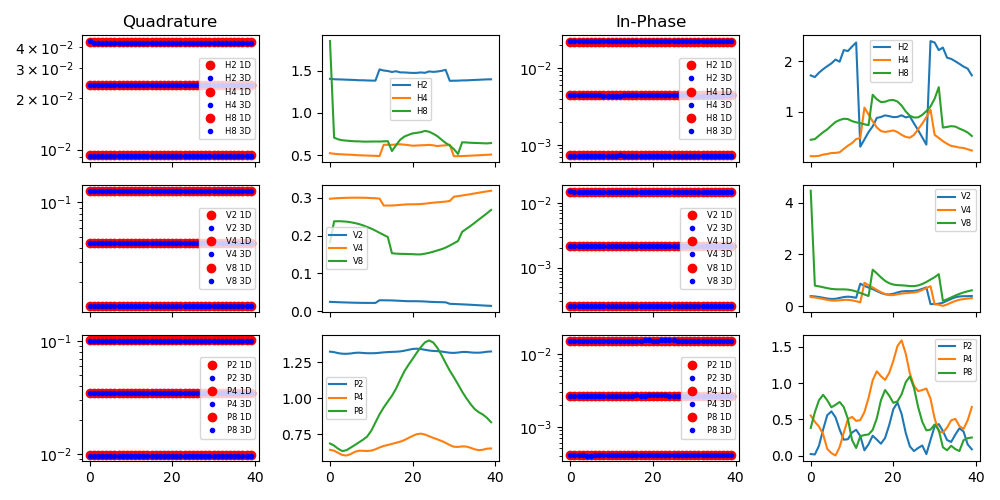

In [9]:
fig, ax = plt.subplots(3,4, sharex=True, figsize=(10,5))

ax[0,0].semilogy(data_1D[:,0], 'or', label='H2 1D')
ax[0,0].semilogy(data_3D[:,0], '.b', label= 'H2 3D')
ax[0,1].plot(100*np.abs((data_1D[:,0] - data_3D[:,0])/data_1D[:,0]), label='H2')

ax[0,0].semilogy(data_1D[:,1], 'or', label='H4 1D')
ax[0,0].semilogy(data_3D[:,1], '.b', label= 'H4 3D')
ax[0,1].plot(100*np.abs((data_1D[:,1] - data_3D[:,1])/data_1D[:,1]), label='H4')

ax[0,0].semilogy(data_1D[:,2], 'or', label='H8 1D')
ax[0,0].semilogy(data_3D[:,2], '.b', label= 'H8 3D')
ax[0,1].plot(100*np.abs((data_1D[:,2] - data_3D[:,2])/data_1D[:,2]), label='H8')
ax[0,0].legend(fontsize=6)
ax[0,1].legend(fontsize=6)
ax[0,0].set_title('Quadrature')

ax[1,0].semilogy(data_1D[:,3], 'or', label='V2 1D')
ax[1,0].semilogy(data_3D[:,3], '.b', label= 'V2 3D')
ax[1,1].plot(100*np.abs((data_1D[:,3] - data_3D[:,3])/data_1D[:,3]), label='V2')

ax[1,0].semilogy(data_1D[:,4], 'or', label='V4 1D')
ax[1,0].semilogy(data_3D[:,4], '.b', label= 'V4 3D')
ax[1,1].plot(100*np.abs((data_1D[:,4] - data_3D[:,4])/data_1D[:,4]), label='V4')

ax[1,0].semilogy(data_1D[:,5], 'or', label='V8 1D')
ax[1,0].semilogy(data_3D[:,5], '.b', label= 'V8 3D')
ax[1,1].plot(100*np.abs((data_1D[:,5] - data_3D[:,5])/data_1D[:,5]), label='V8')
ax[1,0].legend(fontsize=6)
ax[1,1].legend(fontsize=6)

ax[2,0].semilogy(data_1D[:,6], 'or', label='P2 1D')
ax[2,0].semilogy(data_3D[:,6], '.b', label= 'P2 3D')
ax[2,1].plot(100*np.abs((data_1D[:,6] - data_3D[:,6])/data_1D[:,6]), label='P2')

ax[2,0].semilogy(data_1D[:,7], 'or', label='P4 1D')
ax[2,0].semilogy(data_3D[:,7], '.b', label= 'P4 3D')
ax[2,1].plot(100*np.abs((data_1D[:,7] - data_3D[:,7])/data_1D[:,7]), label='P4')

ax[2,0].semilogy(data_1D[:,8], 'or', label='P8 1D')
ax[2,0].semilogy(data_3D[:,8], '.b', label= 'P8 3D')
ax[2,1].plot(100*np.abs((data_1D[:,8] - data_3D[:,8])/data_1D[:,8]), label='P8')
ax[2,0].legend(fontsize=6)
ax[2,1].legend(fontsize=6)

# In-Phase
ax[0,2].semilogy(data_1D[:,9], 'or', label='H2 1D')
ax[0,2].semilogy(data_3D[:,9], '.b', label= 'H2 3D')
ax[0,3].plot(100*np.abs((data_1D[:,9] - data_3D[:,9])/data_1D[:,9]), label='H2')

ax[0,2].semilogy(data_1D[:,10], 'or', label='H4 1D')
ax[0,2].semilogy(data_3D[:,10], '.b', label= 'H4 3D')
ax[0,3].plot(100*np.abs((data_1D[:,10] - data_3D[:,10])/data_1D[:,10]), label='H4')

ax[0,2].semilogy(data_1D[:,11], 'or', label='H8 1D')
ax[0,2].semilogy(data_3D[:,11], '.b', label= 'H8 3D')
ax[0,3].plot(100*np.abs((data_1D[:,11] - data_3D[:,11])/data_1D[:,11]), label='H8')

ax[0,2].legend(fontsize=6)
ax[0,3].legend(fontsize=6)
ax[0,2].set_title('In-Phase')

ax[1,2].semilogy(data_1D[:,12], 'or', label='V2 1D')
ax[1,2].semilogy(data_3D[:,12], '.b', label= 'V2 3D')
ax[1,3].plot(100*np.abs((data_1D[:,12] - data_3D[:,12])/data_1D[:,12]), label='V2')

ax[1,2].semilogy(data_1D[:,13], 'or', label='V4 1D')
ax[1,2].semilogy(data_3D[:,13], '.b', label= 'V4 3D')
ax[1,3].plot(100*np.abs((data_1D[:,13] - data_3D[:,13])/data_1D[:,13]), label='V4')

ax[1,2].semilogy(data_1D[:,14], 'or', label='V8 1D')
ax[1,2].semilogy(data_3D[:,14], '.b', label= 'V8 3D')
ax[1,3].plot(100*np.abs((data_1D[:,14] - data_3D[:,14])/data_1D[:,14]), label='V8')

ax[1,2].legend(fontsize=6)
ax[1,3].legend(fontsize=6)

ax[2,2].semilogy(data_1D[:,15], 'or', label='P2 1D')
ax[2,2].semilogy(data_3D[:,15], '.b', label= 'P2 3D')
ax[2,3].plot(100*np.abs((data_1D[:,15] - data_3D[:,15])/data_1D[:,15]), label='P2')

ax[2,2].semilogy(data_1D[:,16], 'or', label='P4 1D')
ax[2,2].semilogy(data_3D[:,16], '.b', label= 'P4 3D')
ax[2,3].plot(100*np.abs((data_1D[:,16] - data_3D[:,16])/data_1D[:,16]), label='P4')

ax[2,2].semilogy(data_1D[:,17], 'or', label='P8 1D')
ax[2,2].semilogy(data_3D[:,17], '.b', label= 'P8 3D')
ax[2,3].plot(100*np.abs((data_1D[:,17] - data_3D[:,17])/data_1D[:,17]), label='P8')

ax[2,2].legend(fontsize=6)
ax[2,3].legend(fontsize=6)

plt.tight_layout()
